In [37]:
import pandas as pd
import requests

In [38]:
# load the dataset
df = pd.read_csv("crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [39]:
# print dataset info
df.info()
df.isnull().sum()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [40]:
# encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [41]:
# save the label mapping
dict(zip(le.classes_, le.transform(le.classes_)))

{'apple': np.int64(0),
 'banana': np.int64(1),
 'blackgram': np.int64(2),
 'chickpea': np.int64(3),
 'coconut': np.int64(4),
 'coffee': np.int64(5),
 'cotton': np.int64(6),
 'grapes': np.int64(7),
 'jute': np.int64(8),
 'kidneybeans': np.int64(9),
 'lentil': np.int64(10),
 'maize': np.int64(11),
 'mango': np.int64(12),
 'mothbeans': np.int64(13),
 'mungbean': np.int64(14),
 'muskmelon': np.int64(15),
 'orange': np.int64(16),
 'papaya': np.int64(17),
 'pigeonpeas': np.int64(18),
 'pomegranate': np.int64(19),
 'rice': np.int64(20),
 'watermelon': np.int64(21)}

In [42]:
# split features and target
X = df.drop('label', axis=1)
y = df['label']

In [43]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
# train ML models

# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [45]:
# train ML models

# 2. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [46]:
# Evaluate model
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [47]:
# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [48]:
# scores
print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("RF Accuracy:", accuracy_score(y_test, rf_pred))

print("RF F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

LR Accuracy: 0.95
RF Accuracy: 0.9477272727272728
RF F1 Score: 0.9414510853421512


In [49]:
# report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.83      1.00      0.91        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       1.00      0.26      0.41        23
           9       1.00      1.00      1.00        20
          10       0.85      1.00      0.92        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.75      0.86        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

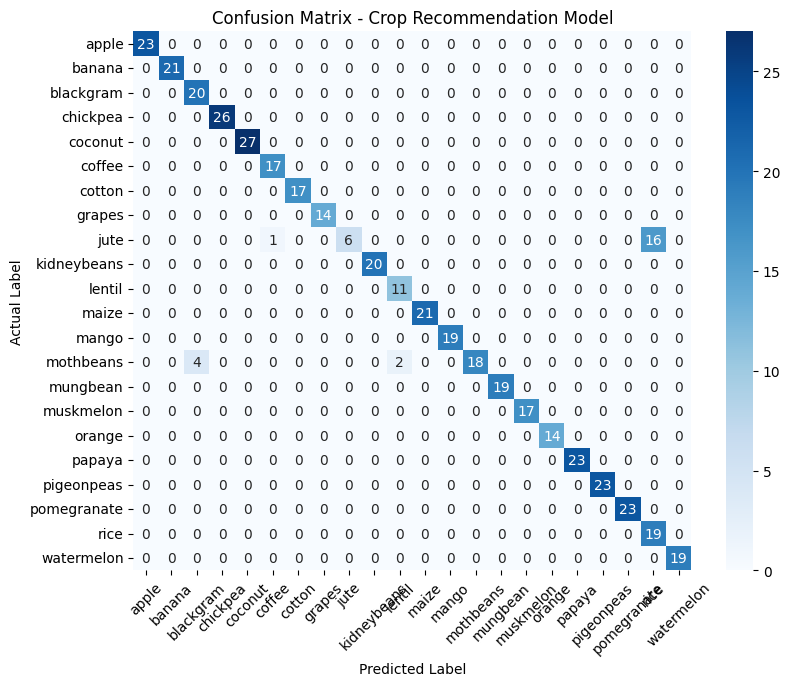

In [50]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

# plt.figure(figsize=(8,6))
# sns.heatmap(cm)
# plt.title("Confusion Matrix")
# plt.show()

# another format
plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt="d",           # integer format
    cmap="Blues",      # clean professional color
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - Crop Recommendation Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [51]:
# Final prediction function
def predict_crop(N, P, K, temp, humidity, ph, rainfall):
    input_data = [[N, P, K, temp, humidity, ph, rainfall]]
    prediction = rf.predict(input_data)
    return le.inverse_transform(prediction)[0]

In [52]:
# predict crop based on sensor data - from firebase
import requests
import json

# url for get data
url = "https://smart-agriculture-78e45-default-rtdb.firebaseio.com/sensorData.json"

params = {
    "orderBy": "\"$key\"",
    "limitToLast": 1
}

response = requests.get(url, params=params)
data = response.json()

# extract last record
last_key = list(data.keys())[0]
last_data = data[last_key]

print("Last Sensor Data:")
print(last_data)

# store value in variables
humidity = last_data['humidity']
lightLevel = last_data['lightLevel']
lightPercentage = last_data['lightPercentage']
moisture = last_data['moisture']
nitrogen = last_data['nitrogen']
phosphorus = last_data['phosphorus']
potassium = last_data['potassium']
temperature = last_data['temperature']

# predict crop
predicted_crop = predict_crop(nitrogen, phosphorus, potassium, temperature, humidity, 6.5, 100)

print("🌾 Recommended Crop:", predicted_crop)

# update recommended crop in firebase
storeUrl = "https://smart-agriculture-78e45-default-rtdb.firebaseio.com/recommendedCrop.json"

data = {
  "name": predicted_crop
}

responsedata = requests.put(storeUrl, data=json.dumps(data))

print(responsedata.status_code)
print(responsedata.text)

# irrigation logic
if moisture < 35:
  irrigation_status = "ON"
  pump_status = "ON"
else:
  irrigation_status = "OFF"
  pump_status = "OFF"

print("💧 Irrigation:", irrigation_status)
print("💧 Pump status:", pump_status)

storeUrl = "https://smart-agriculture-78e45-default-rtdb.firebaseio.com/irrigation.json"

payload = {
  "irrigation_status": irrigation_status,
  "pump_status": pump_status
}

response_store = requests.put(storeUrl, data=json.dumps(payload))

print(response_store.status_code)
print(response_store.text)

Last Sensor Data:
{'humidity': 59.5, 'lightLevel': 1319, 'lightPercentage': 32, 'moisture': 73, 'nitrogen': 76, 'phosphorus': 58, 'potassium': 29, 'temperature': 23.3}
🌾 Recommended Crop: maize
200
{"name":"maize"}
💧 Irrigation: OFF
💧 Pump status: OFF
200
{"irrigation_status":"OFF","pump_status":"OFF"}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [53]:
# save model
import joblib

joblib.dump(rf, "crop_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [54]:
import time
import requests
import json

url = "https://smart-agriculture-78e45-default-rtdb.firebaseio.com/sensorData.json"

last_key = None

while True:
    try:
        response = requests.get(url)
        data = response.json()

        if not data:
            print("No data found")
            time.sleep(5)
            continue

        # get latest entry safely
        latest_key = sorted(data.keys())[-1]
        last_data = data[latest_key]

        # avoid repeating same record
        if latest_key != last_key:
            last_key = latest_key

            print("\n🔥 New Sensor Data:")
            print(last_data)

            # extract values
            humidity = last_data['humidity']
            lightLevel = last_data['lightLevel']
            lightPercentage = last_data['lightPercentage']
            moisture = last_data['moisture']
            nitrogen = last_data['nitrogen']
            phosphorus = last_data['phosphorus']
            potassium = last_data['potassium']
            temperature = last_data['temperature']

            # prediction
            predicted_crop = predict_crop(
                nitrogen, phosphorus, potassium,
                temperature, humidity,
                6.5, 100
            )

            print("🌾 Recommended Crop:", predicted_crop)

            # store result in Firebase
            storeUrl = "https://smart-agriculture-78e45-default-rtdb.firebaseio.com/recommendedCrop.json"

            payload = {
                "name": predicted_crop
            }

            response_store = requests.put(storeUrl, data=json.dumps(payload))

            print("Firebase update:", response_store.status_code)

            # irrigation logic
            if moisture < 35:
              irrigation_status = "ON"
              pump_status = "ON"
            else:
              irrigation_status = "OFF"
              pump_status = "OFF"

            print("💧 Irrigation:", irrigation_status)
            print("💧 Pump status:", pump_status)

            storeUrl = "https://smart-agriculture-78e45-default-rtdb.firebaseio.com/irrigation.json"

            payload = {
              "irrigation_status": irrigation_status,
              "pump_status": pump_status
            }

            response_store = requests.put(storeUrl, data=json.dumps(payload))

            print(response_store.status_code)
            print(response_store.text)

        time.sleep(5)

    except Exception as e:
        print("Error:", e)
        time.sleep(5)


🔥 New Sensor Data:
{'humidity': 59.5, 'lightLevel': 1319, 'lightPercentage': 32, 'moisture': 73, 'nitrogen': 76, 'phosphorus': 58, 'potassium': 29, 'temperature': 23.3}
🌾 Recommended Crop: maize
Firebase update: 200
💧 Irrigation: OFF
💧 Pump status: OFF
200
{"irrigation_status":"OFF","pump_status":"OFF"}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


KeyboardInterrupt: 